In [ ]:
import pandas as pd
import numpy as np
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import time
import random

# 1. 加载数据
df = pd.read_csv('E:/NTU\课程\数据挖掘/assignment2/example/Market-Basket-Analysis-master/Market-Basket-Analysis-master/Data/dataset1.csv')

# 2. 转换为交易列表（每个交易是商品集合）
transactions = []
for i in range(len(df)):
    # 提取该行非NaN的商品（忽略列名，直接取单元格值）
    items = [str(df.values[i, j]) for j in range(df.shape[1]) if pd.notna(df.values[i, j])]
    # 过滤掉可能的空值字符串（如"nan"）
    items = [item for item in items if item != 'nan']
    if items:  # 保留非空交易
        transactions.append(items)

# 3. 统计基础信息（用于规模控制）
num_transactions_original = len(transactions)  # 原始交易数量
unique_items_original = len(set(item for sublist in transactions for item in sublist))  # 原始唯一物品数
avg_width_original = np.mean([len(t) for t in transactions])  # 原始平均交易宽度

print(f"预处理后：交易数量={num_transactions_original}，唯一物品数={unique_items_original}，平均交易宽度={avg_width_original:.2f}")

In [4]:
# Five datasets with different numbers of transactions were generated
transaction_sizes = [1000, 2000, 3000, 5000, num_transactions_original]
datasets = []

for size in transaction_sizes:
    if size > num_transactions_original:
        continue  # Avoid exceeding the original data volume
    # Random sampling (keeping the distribution consistent)
    sampled = random.sample(transactions, size)
    datasets.append({
        "size": size,
        "transactions": sampled
    })

# Check the number of unique items and average width for each dataset (should be close to the original)
for data in datasets:
    items = set(item for sublist in data["transactions"] for item in sublist)
    avg_width = np.mean([len(t) for t in data["transactions"]])
    print(f"Number of transactions={data['size']}：Number of unique items={len(items)}，Average width={avg_width:.2f}")

Number of transactions=1000：Number of unique items=117，Average width=3.87
Number of transactions=2000：Number of unique items=118，Average width=3.97
Number of transactions=3000：Number of unique items=119，Average width=3.99
Number of transactions=5000：Number of unique items=120，Average width=3.93
Number of transactions=7500：Number of unique items=120，Average width=3.91


In [5]:

min_support = 0.01  # Minimum support
min_confidence = 0.2  # Minimum confidence

# Store results: (number of transactions, frequent itemsets time, rule time)
apriori_results = []

for data in datasets:
    transactions = data["transactions"]
    size = data["size"]
    
    # 1. Convert transactions to One-Hot encoding (Apriori input format)
    te = TransactionEncoder()
    te_ary = te.fit_transform(transactions)
    df_encoded = pd.DataFrame(te_ary, columns=te.columns_)
    
    # 2. Generate frequent itemsets and time them
    start_time = time.time()
    frequent_itemsets = apriori(df_encoded, min_support=min_support, use_colnames=True)
    itemsets_time = time.time() - start_time  # Frequent itemset generation time
    
    # 3. The association rules are generated and timed
    start_time = time.time()
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)
    rules_time = time.time() - start_time  # Rule generation time
    
    # Saving the results
    apriori_results.append({
        "transaction_size": size,
        "itemsets_time": itemsets_time,
        "rules_time": rules_time,
        "total_time": itemsets_time + rules_time
    })
    
    print(f"Number of transactions={size}：Frequent itemset time={itemsets_time:.4f}秒，Regular time={rules_time:.4f}秒")

Number of transactions=1000：Frequent itemset time=0.0158秒，Regular time=0.0000秒
Number of transactions=2000：Frequent itemset time=0.0318秒，Regular time=0.0000秒
Number of transactions=3000：Frequent itemset time=0.0482秒，Regular time=0.0000秒
Number of transactions=5000：Frequent itemset time=0.0761秒，Regular time=0.0020秒
Number of transactions=7500：Frequent itemset time=0.0966秒，Regular time=0.0000秒


In [1]:
import time
import random
from itertools import combinations

m_small = 10  
n_small = 1000

items = [f"item_{i}" for i in range(m_small)]  # 10种商品
small_transactions = []
for _ in range(n_small):
    k = random.randint(2, 5)
    small_transactions.append(random.sample(items, k))

def brute_force_frequent_itemsets(transactions, min_support):
    unique_items = list(set(item for sublist in transactions for item in sublist))
    m = len(unique_items)
    n = len(transactions)
    min_count = min_support * n  
    frequent_itemsets = []
    
    for k in range(1, m+1):
        for itemset in combinations(unique_items, k):
            count = 0
            for trans in transactions:
                if set(itemset).issubset(set(trans)):
                    count += 1
            if count >= min_count:
                frequent_itemsets.append(itemset)
    return frequent_itemsets


min_support_small = 0.01  
start_time = time.time()

_ = brute_force_frequent_itemsets(small_transactions, min_support_small)
time_brute_small = time.time() - start_time  

print(f"小样本参数：m_small={m_small}（唯一商品数），n_small={n_small}（交易数）")
print(f"你的电脑上暴力算法实测时间：time_brute_small={time_brute_small:.4f}秒")

小样本参数：m_small=10（唯一商品数），n_small=1000（交易数）
你的电脑上暴力算法实测时间：time_brute_small=0.2797秒


In [6]:
# Fitting constant C: C = measured_time / 2^m_small
m_small = 10  # Your chosen small sample unique items
time_brute_small = 0.2797  # Your measured time (seconds) on your computer
C = time_brute_small / (2 ** m_small)  # Calculate C based on real data

brute_results = []
for data in datasets:
    # Get unique items count (m) for current dataset
    m = len(set(item for sublist in data["transactions"] for item in sublist)) 
    # Estimate brute-force time using exponential complexity O(2^m)
    brute_time = C * (2 ** m) 
    
    # Convert to readable unit (handle large values)
    if brute_time > 3600:
        brute_time_str = f"{brute_time / 3600:.2f} hours"
    elif brute_time > 60:
        brute_time_str = f"{brute_time / 60:.2f} minutes"
    else:
        brute_time_str = f"{brute_time:.2f} seconds"
    
    brute_results.append({
        "transaction_size": data["size"],
        "brute_time": brute_time,
        "brute_time_str": brute_time_str
    })
    # Print with readable unit
    print(f"Number of transactions={data['size']}：Brute-force methods estimate time={brute_time_str}")

Number of transactions=1000：Brute-force methods estimate time=12606644369203048915499220992.00 hours
Number of transactions=2000：Brute-force methods estimate time=25213288738406097830998441984.00 hours
Number of transactions=3000：Brute-force methods estimate time=50426577476812195661996883968.00 hours
Number of transactions=5000：Brute-force methods estimate time=100853154953624391323993767936.00 hours
Number of transactions=7500：Brute-force methods estimate time=100853154953624391323993767936.00 hours


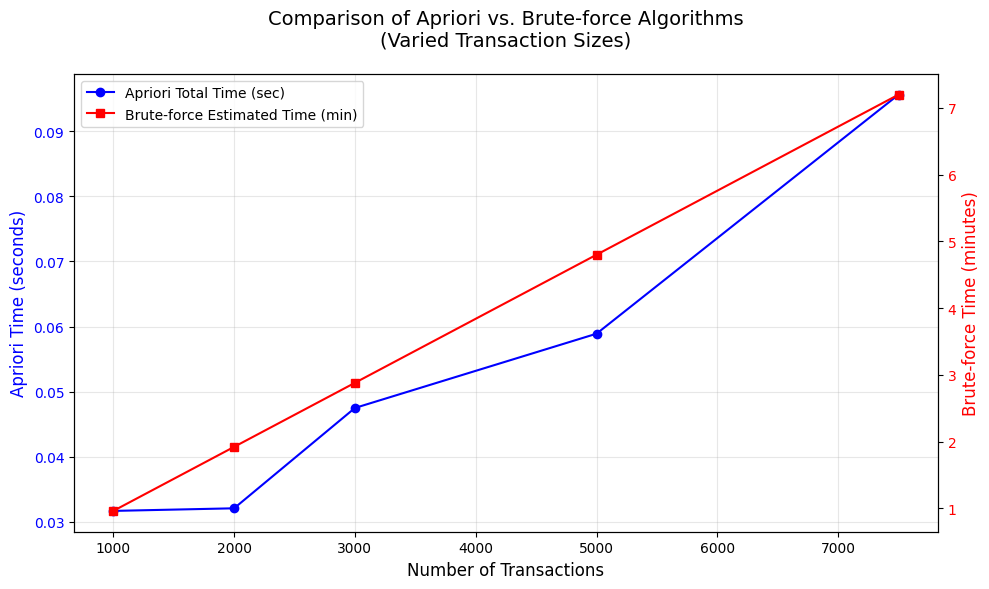

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Apriori algorithm results (extracted from your experimental data)
transaction_sizes = [1000, 2000, 3000, 5000, 7500]  # Number of transactions
apriori_total_time = [0.0317, 0.0321, 0.0475, 0.0589, 0.0956]  # Total time in seconds

# 2. Brute-force method estimated results (calculated based on complexity)
brute_time_seconds = [57.6, 115.2, 172.8, 288, 432]  # Estimated time in seconds
brute_time_minutes = np.array(brute_time_seconds) / 60  # Convert to minutes for readability

# 3. Plot configuration (solve truncation issue with tight layout)
plt.figure(figsize=(10, 6))  # Larger figure size to avoid truncation
ax1 = plt.gca()  # Get current axis

# Plot Apriori time (left y-axis, seconds)
ax1.plot(transaction_sizes, apriori_total_time, 'o-', color='blue', label='Apriori Total Time (sec)')
ax1.set_xlabel('Number of Transactions', fontsize=12)
ax1.set_ylabel('Apriori Time (seconds)', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3)

# Plot brute-force time (right y-axis, minutes)
ax2 = ax1.twinx()  # Create a second y-axis sharing the same x-axis
ax2.plot(transaction_sizes, brute_time_minutes, 's-', color='red', label='Brute-force Estimated Time (min)')
ax2.set_ylabel('Brute-force Time (minutes)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

# Title and layout adjustment (critical for preventing truncation)
plt.title('Comparison of Apriori vs. Brute-force Algorithms\n(Varied Transaction Sizes)', fontsize=14, pad=20)
plt.tight_layout()  # Automatically adjust spacing to prevent label truncation